<a href="https://colab.research.google.com/github/xyz111131/AI-Tools-for-Statistical-Research/blob/main/logistic_regression_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression with PyTorch

This notebook implements logistic regression using PyTorch's neural network class (`nn.Module`), with an explicit loss function and optimizer.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

## 1. Load and Prepare Data

We use the Breast Cancer Wisconsin dataset (binary classification) as a demonstration.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(f"Training samples: {X_train.shape[0]}, Features: {X_train.shape[1]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 455, Features: 30
Test samples: 114


## 2. Define the Logistic Regression Model

Logistic regression is a single linear layer followed by a sigmoid activation. We implement it as an `nn.Module` subclass.

In [3]:
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))


input_dim = X_train.shape[1]
model = LogisticRegression(input_dim)
print(model)

LogisticRegression(
  (linear): Linear(in_features=30, out_features=1, bias=True)
)


## 3. Specify Loss Function and Optimizer

- **Loss**: Binary Cross-Entropy (`nn.BCELoss`) — the standard loss for binary classification with sigmoid output.
- **Optimizer**: Stochastic Gradient Descent (`optim.SGD`) with a learning rate of 0.01.

In [4]:
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

## 4. Train the Model

In [5]:
num_epochs = 200
train_losses = []

for epoch in range(num_epochs):
    model.train()

    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [20/200], Loss: 0.4495
Epoch [40/200], Loss: 0.3591
Epoch [60/200], Loss: 0.3080
Epoch [80/200], Loss: 0.2744
Epoch [100/200], Loss: 0.2503
Epoch [120/200], Loss: 0.2319
Epoch [140/200], Loss: 0.2174
Epoch [160/200], Loss: 0.2055
Epoch [180/200], Loss: 0.1956
Epoch [200/200], Loss: 0.1872


## 5. Plot Training Loss

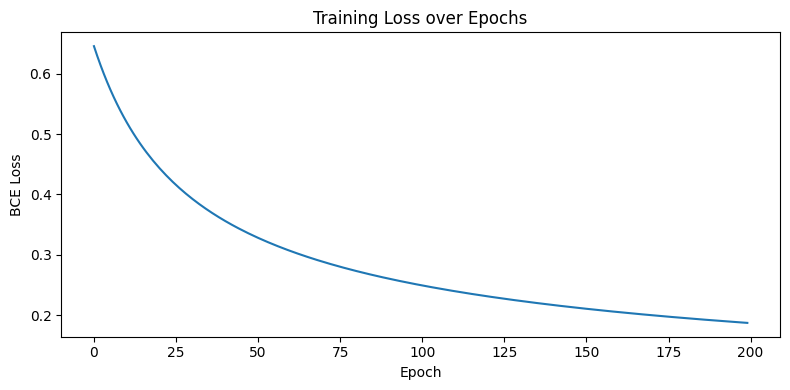

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training Loss over Epochs")
plt.tight_layout()
plt.show()

## 6. Evaluate on Test Set

In [7]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)
    y_pred_labels = (y_pred_test >= 0.5).float()

accuracy = accuracy_score(y_test.numpy(), y_pred_labels.numpy())
print(f"Test Accuracy: {accuracy:.4f}\n")
print(classification_report(
    y_test.numpy(), y_pred_labels.numpy(),
    target_names=data.target_names
))

Test Accuracy: 0.9825

              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 7. Inspect Learned Parameters

In [8]:
weights = model.linear.weight.detach().numpy().flatten()
bias = model.linear.bias.detach().numpy()

print(f"Bias: {bias[0]:.4f}")
print(f"\nTop 5 features by absolute weight:")
top_idx = np.argsort(np.abs(weights))[::-1][:5]
for i in top_idx:
    print(f"  {data.feature_names[i]:>25s}: {weights[i]:.4f}")

Bias: 0.2225

Top 5 features by absolute weight:
            worst perimeter: -0.3624
                 worst area: -0.3277
            perimeter error: -0.2917
                  mean area: -0.2887
               mean texture: -0.2607
